In [2]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import os


In [3]:
os.listdir("/eos/")

['dev', 'unmerged', 'usc', 'uscms', 'uscmst1prod.fnal.gov']

In [ ]:
import uproot
import awkward as ak

# The public WebDAV URL from CERNBox
file_url = "https://cernbox.cern.ch/remote.php/dav/public-files/T1d5z5r28dwh8gV/NanoFull.root"

try:
    # Uproot can open the file directly from the URL!
    # It streams the data without needing to download the whole file first.
    with uproot.open(file_url) as file:
        print("✅ Successfully opened the file remotely!")
        
        # --- You can now work with the file as usual ---
        
        # See what TTrees are inside
        print("\nAvailable TTree names:", file.keys())
        
        # Access the 'Events' TTree
        tree = file["Events"]
        print("\nEvents TTree object:", tree)
        
        # Load a few branches into an awkward array
        # Use a small entry_stop for a quick test
        branches = tree.arrays(
            ["nScoutingJet", "ScoutingJet_pt", "ScoutingJet_eta"],
            entry_stop=100
        )
        
        print("\nFirst 5 events for 'ScoutingJet_pt':")
        print(branches["ScoutingJet_pt"][:5])

except Exception as e:
    print(f"❌ Failed to open the file. Error: {e}")
    print("This could be due to a network issue, a change in the public link, or a firewall.")

OSError: remote server responded with status 502, rather than 206 (range requests)
for URL https://cernbox.cern.ch/remote.php/dav/public-files/T1d5z5r28dwh8gV/NanoFull.root

In [4]:

file_name = "step1_NANO.root"
f = uproot.open(file_name)
f.keys()


['Events;1', 'LuminosityBlocks;1', 'Runs;1', 'MetaData;1', 'ParameterSets;1']

In [5]:
tree_name = "LuminosityBlocks"         
tree = uproot.open(file_name)[tree_name]
display(tree.show())

print((tree["run"], tree["luminosityBlock"]))
print()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
run                  | uint32_t                 | AsDtype('>u4')
luminosityBlock      | uint32_t                 | AsDtype('>u4')


None

(<TBranch 'run' at 0x7ff6376f56d0>, <TBranch 'luminosityBlock' at 0x7ff637838e90>)



In [6]:
tree_name = "Events"         
tree = uproot.open(file_name)[tree_name]
tree.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
run                  | uint32_t                 | AsDtype('>u4')
luminosityBlock      | uint32_t                 | AsDtype('>u4')
event                | uint64_t                 | AsDtype('>u8')
bunchCrossing        | uint32_t                 | AsDtype('>u4')
orbitNumber          | uint32_t                 | AsDtype('>u4')
nScoutingJet         | int32_t                  | AsDtype('>i4')
ScoutingJet_nCons... | uint8_t[]                | AsJagged(AsDtype('uint8'))
ScoutingJet_nCh      | int32_t[]                | AsJagged(AsDtype('>i4'))
ScoutingJet_nElec... | int32_t[]                | AsJagged(AsDtype('>i4'))
ScoutingJet_nMuons   | int32_t[]                | AsJagged(AsDtype('>i4'))
ScoutingJet_nNh      | int32_t[]                | AsJagged(AsDtype('>i4'))
ScoutingJet_nPhotons | int32_t[]                | AsJagged(AsDtype('>i4

In [ ]:
for b in tree.keys():
    print(b)

run
luminosityBlock
event
bunchCrossing
orbitNumber
nScoutingJet
ScoutingJet_nConstituents
ScoutingJet_nCh
ScoutingJet_nElectrons
ScoutingJet_nMuons
ScoutingJet_nNh
ScoutingJet_nPhotons
ScoutingJet_area
ScoutingJet_chEmEF
ScoutingJet_chHEF
ScoutingJet_eta
ScoutingJet_mass
ScoutingJet_muEF
ScoutingJet_neEmEF
ScoutingJet_neHEF
ScoutingJet_phi
ScoutingJet_pt
ScoutingJet_particleNet_prob_b
ScoutingJet_particleNet_prob_bb
ScoutingJet_particleNet_prob_c
ScoutingJet_particleNet_prob_cc
ScoutingJet_particleNet_prob_g
ScoutingJet_particleNet_prob_undef
ScoutingJet_particlenet_prob_uds
nScoutingFatJet
ScoutingFatJet_nConstituents
ScoutingFatJet_nCh
ScoutingFatJet_nElectrons
ScoutingFatJet_nMuons
ScoutingFatJet_nNh
ScoutingFatJet_nPhotons
ScoutingFatJet_area
ScoutingFatJet_chEmEF
ScoutingFatJet_chHEF
ScoutingFatJet_eta
ScoutingFatJet_mass
ScoutingFatJet_muEF
ScoutingFatJet_neEmEF
ScoutingFatJet_neHEF
ScoutingFatJet_phi
ScoutingFatJet_pt
ScoutingFatJet_msoftdrop
ScoutingFatJet_n2b1
ScoutingFatJet_

In [10]:
# ScoutingJet_genJetIdx
# ScoutingFatJet_genJetAK8Idx

print(tree["ScoutingJet_genJetIdx"].array())
print(tree["ScoutingFatJet_genJetAK8Idx"].array())

[[1, 0, 4, -99999], [0, 1, 3, ... [0, 1, 2, 3, -99999, -99999, -99999, -99999]]
[[], [], [], [], [], [], [], [], [], []]


In [9]:
for b in ["GenPart_pdgId",
          "Tau_pt",
          "Jet_btagDeepFlavB"]:
    print(f"{b:20s}", "✓" if b in tree.keys() else "✗")


GenPart_pdgId        ✗
Tau_pt               ✗
Jet_btagDeepFlavB    ✗


In [10]:

def branches_matching(prefix):
    """Return list of branch names that start with *prefix*."""
    return [b for b in tree.keys() if b.startswith(prefix)]

hlt_branches  = branches_matching("HLT_")
l1_branches   = branches_matching("L1_")
dst_branches  = branches_matching("DST_")
scout_flags   = branches_matching("Dataset_Scouting")

print(f"#HLT  : {len(hlt_branches)}\n"
      f"#L1  : {len(l1_branches)}\n"
      f"#DST : {len(dst_branches)}\n"
      f"#Scouting flags: {scout_flags}")


#HLT  : 688
#L1  : 412
#DST : 5
#Scouting flags: ['Dataset_ScoutingPFMonitor', 'Dataset_ScoutingPFRun3']


In [11]:
dst_branches

['DST_Run3_DoubleMu3_PFScoutingPixelTracking',
 'DST_Run3_EG30_PFScoutingPixelTracking',
 'DST_Run3_EG16_EG12_PFScoutingPixelTracking',
 'DST_Run3_JetHT_PFScoutingPixelTracking',
 'DST_HLTMuon_Run3_PFScoutingPixelTracking']

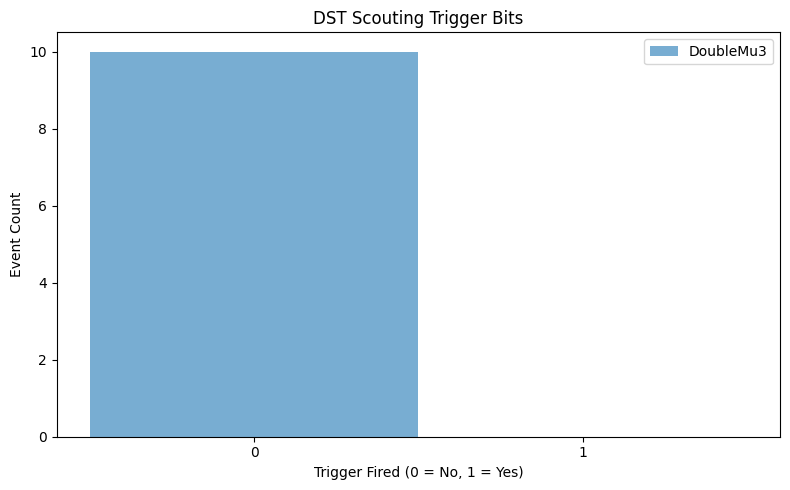

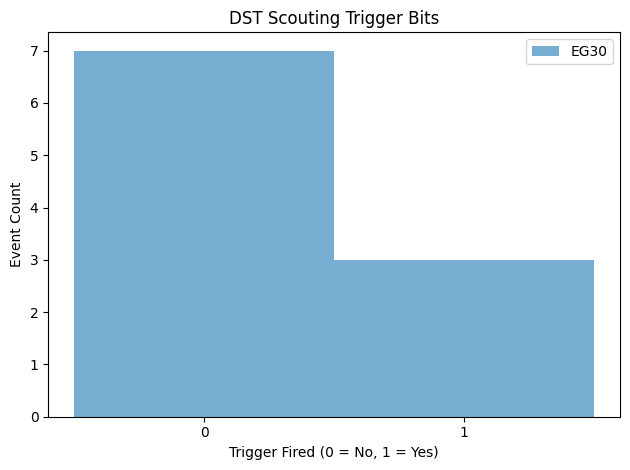

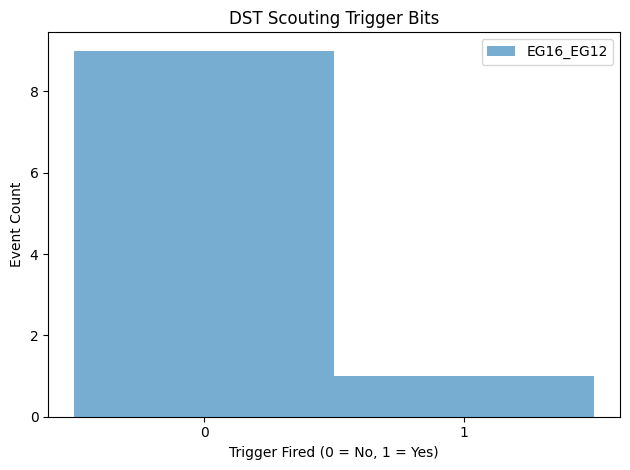

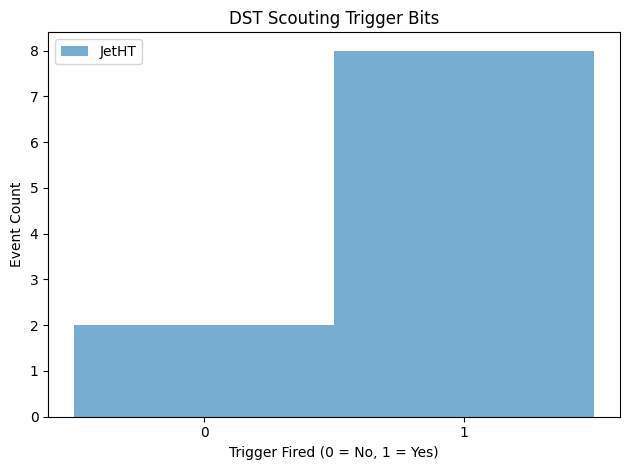

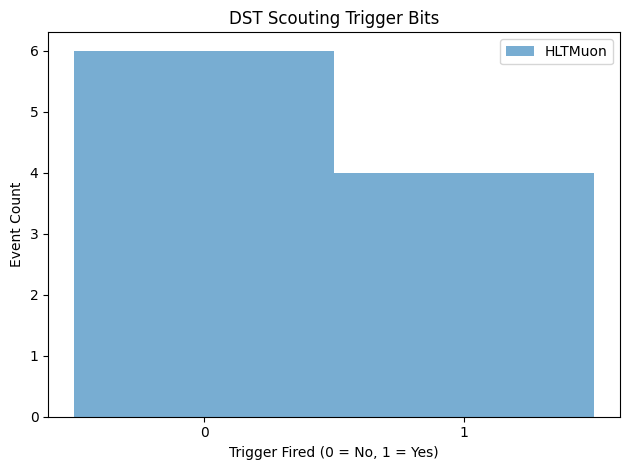

In [12]:
scouting_trigger_map = {
    "DoubleMu3":  "DST_Run3_DoubleMu3_PFScoutingPixelTracking",
    "EG30":       "DST_Run3_EG30_PFScoutingPixelTracking",
    "EG16_EG12":  "DST_Run3_EG16_EG12_PFScoutingPixelTracking",
    "JetHT":      "DST_Run3_JetHT_PFScoutingPixelTracking",
    "HLTMuon":    "DST_HLTMuon_Run3_PFScoutingPixelTracking"
}

# --- Read only the selected triggers
branch_list = list(scouting_trigger_map.values())
scouting_trig = tree.arrays(branch_list, library="ak")

# --- Histogram each trigger (converted to int)
plt.figure(figsize=(8, 5))
for label, branch in scouting_trigger_map.items():
    data = ak.values_astype(scouting_trig[branch], np.int_)
    plt.hist(data, bins=[-0.5, 0.5, 1.5], alpha=0.6, label=label)

    plt.xlabel("Trigger Fired (0 = No, 1 = Yes)")
    plt.ylabel("Event Count")
    plt.title("DST Scouting Trigger Bits")
    plt.xticks([0, 1])
    plt.legend()
    plt.tight_layout()
    plt.show()


In [71]:
bits = tree.arrays(dst_branches, library="ak")
N_total = len(bits[dst_branches[0]])

print(f"{'Trigger bit':55}  Efficiency")
print("-"*70)

eff_list = []
for b in dst_branches:
    fired = ak.sum(bits[b])
    eff   = fired / N_total
    err   = np.sqrt(eff*(1-eff)/N_total)
    eff_list.append((b, eff, err))

# sort by largest efficiency first (optional)
eff_list.sort(key=lambda t: t[1], reverse=True)

for b, eff, err in eff_list:
    print(f"{b:55}  {eff:7.4f} +/- {err:7.4f}")

# ---------- global OR of all DST bits ----------
any_scout = np.logical_or.reduce([bits[b] for b in dst_branches])
N_fired   = ak.sum(any_scout)
eff_glob  = N_fired / N_total
err_glob  = np.sqrt(eff_glob*(1-eff_glob)/N_total)

print("\n" + "="*70)
print(f"GLOBAL Scouting menu (OR of all {len(dst_branches)} bits)")
print(f"Efficiency: {eff_glob:7.4f} +/- {err_glob:7.4f}")

Trigger bit                                              Efficiency
----------------------------------------------------------------------
DST_Run3_JetHT_PFScoutingPixelTracking                    0.6700 +/-  0.0470
DST_HLTMuon_Run3_PFScoutingPixelTracking                  0.3900 +/-  0.0488
DST_Run3_EG30_PFScoutingPixelTracking                     0.1900 +/-  0.0392
DST_Run3_DoubleMu3_PFScoutingPixelTracking                0.0600 +/-  0.0237
DST_Run3_EG16_EG12_PFScoutingPixelTracking                0.0200 +/-  0.0140

GLOBAL Scouting menu (OR of all 5 bits)
Efficiency:  0.8800 +/-  0.0325


/tmp/ipykernel_51024/659198144.py:20: RuntimeWarning: invalid value encountered in divide
  err  = np.sqrt(eff*(1-eff)/den_hist, where=den_hist!=0)


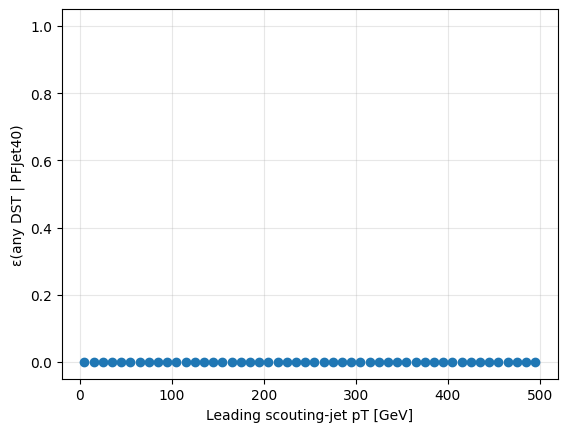

In [65]:
def efficiency_or(tree, num_mask, den_bit, probe_branch, bins, leading=True):
    """Efficiency of an *arbitrary array mask* vs probe."""
    arr = tree.arrays([den_bit, probe_branch], library="ak")
    probe = arr[probe_branch]
    if leading:
        probe = ak.firsts(probe)

    # mask lengths must match probe length (one per event)
    valid = ~ak.is_none(probe)
    probe = probe[valid]
    den   = arr[den_bit][valid]
    num   = num_mask[valid] & den           # enforce denominator

    x   = ak.to_numpy(probe)
    den_hist, _ = np.histogram(x[den], bins=bins)
    num_hist, _ = np.histogram(x[num], bins=bins)

    eff  = np.divide(num_hist, den_hist, out=np.zeros_like(num_hist, float),
                     where=den_hist!=0)
    err  = np.sqrt(eff*(1-eff)/den_hist, where=den_hist!=0)
    centres = 0.5*(bins[1:]+bins[:-1])
    return centres, eff, err

# --- example: leading scouting-jet pT --------------------------------------
bins = np.linspace(0, 500, 51)
cent, eff, err = efficiency_or(tree,
                               num_mask   = any_scout,
                               den_bit    = "HLT_PFJet40_GPUvsCPU",
                               probe_branch = "ScoutingJet_pt",
                               bins       = bins)

import matplotlib.pyplot as plt
plt.errorbar(cent, eff, yerr=err, fmt="o")
plt.xlabel("Leading scouting-jet pT [GeV]")
plt.ylabel("ε(any DST | PFJet40)")
plt.ylim(-0.05, 1.05); plt.grid(alpha=.3)
plt.show()


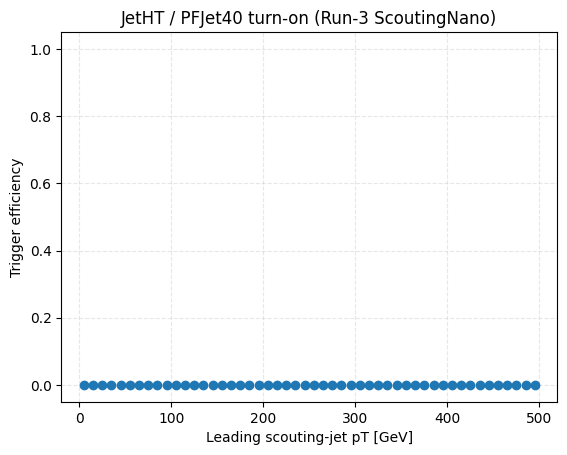

In [62]:
bins = np.linspace(0, 500, 51)               # 10 GeV steps

cent, eps, deps = efficiency(tree,
                             num_bit      = "DST_Run3_JetHT_PFScoutingPixelTracking",
                             den_bit      = "HLT_PFJet40_GPUvsCPU",
                             probe_branch = "ScoutingJet_pt",
                             bins         = bins,
                             leading      = True)

plt.errorbar(cent, eps, yerr=deps, fmt="o")
plt.xlabel("Leading scouting-jet pT [GeV]")
plt.ylabel("Trigger efficiency")
plt.ylim(-0.05, 1.05); plt.grid(ls="--", alpha=.3)
plt.title("JetHT / PFJet40 turn-on (Run-3 ScoutingNano)")
plt.show()


In [57]:
lumi, = tree.arrays(["ScoutingRho"], library="np")   # proxy for PU / lumi
bit   = tree.arrays(["DST_Run3_JetHT_PFScoutingPixelTracking"],
                    library="np")[0]
plt.hist2d(lumi, bit.astype(int), bins=[100,2], cmap="Blues")
plt.xlabel("ρ (proxy for inst. lumi)"); plt.ylabel("JetHT fired")
plt.colorbar(label="Events / bin")
plt.title("JetHT trigger rate vs lumi")
plt.show()


KeyError: 0